In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

RANDOM_STATE = 823

In [2]:
file_name = "healthcare-dataset-stroke-data.csv"

github_path = Path(file_name)

local_path = Path(
    r"C:\Users\aclan\Documents\HI 823\Final Exam\Dataset\healthcare-dataset-stroke-data.csv"
)

if github_path.exists():
    file_path = github_path
elif local_path.exists():
    file_path = local_path
else:
    raise FileNotFoundError(
        "CSV file not found. Place healthcare-dataset-stroke-data.csv "
        "in the same folder as this notebook."
    )

df = pd.read_csv(file_path)

print("Dataset loaded from:")
print(file_path)

df.head()

Dataset loaded from:
C:\Users\aclan\Documents\HI 823\Final Exam\Dataset\healthcare-dataset-stroke-data.csv


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nVariables:")
for column in df.columns:
    print(column)

Number of rows: 5110
Number of columns: 12

Variables:
id
gender
age
hypertension
heart_disease
ever_married
work_type
Residence_type
avg_glucose_level
bmi
smoking_status
stroke


In [4]:
df.head(50)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,5110.0,NaN,NaN,NaN,36517.829354,21161.721625,67.0,17741.25,36932.0,54682.0,72940.0
gender,5110,3,Female,2994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5110.0,NaN,NaN,NaN,43.226614,22.612647,0.08,25.0,45.0,61.0,82.0
hypertension,5110.0,NaN,NaN,NaN,0.097456,0.296607,0.0,0.0,0.0,0.0,1.0
heart_disease,5110.0,NaN,NaN,NaN,0.054012,0.226063,0.0,0.0,0.0,0.0,1.0
ever_married,5110,2,Yes,3353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_type,5110,5,Private,2925,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Residence_type,5110,2,Urban,2596,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_glucose_level,5110.0,NaN,NaN,NaN,106.147677,45.28356,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,NaN,NaN,NaN,28.893237,7.854067,10.3,23.5,28.1,33.1,97.6


In [7]:
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percent": (df.isnull().sum() / len(df)) * 100
})

missing

,Missing,Percent
id,0,0.000000
gender,0,0.000000
age,0,0.000000
hypertension,0,0.000000
heart_disease,0,0.000000
ever_married,0,0.000000
work_type,0,0.000000
Residence_type,0,0.000000
avg_glucose_level,0,0.000000
bmi,201,3.933464


In [8]:
stroke_counts = df["stroke"].value_counts().sort_index()

stroke_percent = (
    df["stroke"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

stroke_summary = pd.DataFrame({
    "Count": stroke_counts,
    "Percent": stroke_percent
})

stroke_summary.index = ["No Stroke", "Stroke"]

stroke_summary

,Count,Percent
No Stroke,4861,95.127202
Stroke,249,4.872798


In [9]:
stroke_probability = df["stroke"].mean()

print(f"Probability of stroke: {stroke_probability:.4f}")
print(f"Percentage with stroke: {stroke_probability * 100:.2f}%")

Probability of stroke: 0.0487
Percentage with stroke: 4.87%


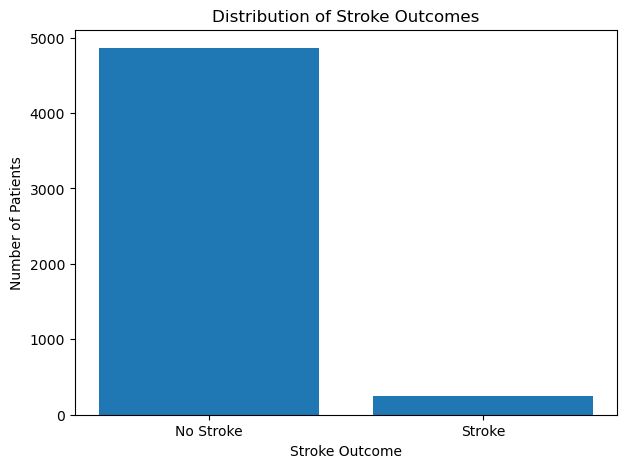

In [10]:
labels = ["No Stroke", "Stroke"]
counts = df["stroke"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(labels, counts)
plt.title("Distribution of Stroke Outcomes")
plt.xlabel("Stroke Outcome")
plt.ylabel("Number of Patients")
plt.show()

In [11]:
hypertension_stroke = pd.crosstab(
    df["hypertension"],
    df["stroke"],
    normalize="index"
) * 100

hypertension_stroke.columns = ["No Stroke (%)", "Stroke (%)"]

hypertension_stroke

,No Stroke (%),Stroke (%)
hypertension,,
0,96.032090,3.967910
1,86.746988,13.253012


In [12]:
heart_stroke = pd.crosstab(
    df["heart_disease"],
    df["stroke"],
    normalize="index"
) * 100

heart_stroke.columns = ["No Stroke (%)", "Stroke (%)"]

heart_stroke

,No Stroke (%),Stroke (%)
heart_disease,,
0,95.821266,4.178734
1,82.971014,17.028986


In [13]:
smoking_stroke = pd.crosstab(
    df["smoking_status"],
    df["stroke"],
    normalize="index"
) * 100

smoking_stroke.columns = ["No Stroke (%)", "Stroke (%)"]

smoking_stroke

,No Stroke (%),Stroke (%)
smoking_status,,
Unknown,96.955959,3.044041
formerly smoked,92.090395,7.909605
never smoked,95.243129,4.756871
smokes,94.676806,5.323194


In [14]:
df.groupby("stroke")["age"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
stroke,,,,
0,4861,41.971545,43.0,22.291940
1,249,67.728193,71.0,12.727419


In [15]:
df.groupby("stroke")["avg_glucose_level"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
stroke,,,,
0,4861,104.795513,91.47,43.846069
1,249,132.544739,105.22,61.921056


In [16]:
df.groupby("stroke")["bmi"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
stroke,,,,
0,4700,28.823064,28.0,7.908287
1,209,30.471292,29.7,6.329452


In [17]:
X = df.drop(columns=["id", "stroke"])
y = df["stroke"]

numeric_features = [
    "age",
    "avg_glucose_level",
    "bmi"
]

binary_features = [
    "hypertension",
    "heart_disease"
]

categorical_features = [
    "gender",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

print("Predictors:", X.shape[1])
print("Target: stroke")

Predictors: 10
Target: stroke


In [18]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("bin", binary_pipeline, binary_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining stroke rate:")
print(y_train.value_counts(normalize=True))

print("\nTesting stroke rate:")
print(y_test.value_counts(normalize=True))

Training observations: 4088
Testing observations: 1022

Training stroke rate:
stroke
0    0.951321
1    0.048679
Name: proportion, dtype: float64

Testing stroke rate:
stroke
0    0.951076
1    0.048924
Name: proportion, dtype: float64


In [20]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

lasso_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegressionCV(
        Cs=10,
        cv=cv,
        penalty="l1",
        solver="saga",
        scoring="roc_auc",
        class_weight="balanced",
        max_iter=10000,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

lasso_model.fit(X_train, y_train)

print("LASSO model completed.")

LASSO model completed.


In [21]:
feature_names = (
    lasso_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    lasso_model
    .named_steps["model"]
    .coef_[0]
)

lasso_results = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

lasso_selected = lasso_results[
    lasso_results["Coefficient"].abs() > 0.000001
].copy()

lasso_selected["Absolute_Coefficient"] = (
    lasso_selected["Coefficient"].abs()
)

lasso_selected = lasso_selected.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

lasso_selected

,Feature,Coefficient,Absolute_Coefficient
0,num__age,1.613497,1.613497
14,cat__smoking_status_never smoked,-0.202394,0.202394
4,bin__heart_disease,0.191195,0.191195
1,num__avg_glucose_level,0.146883,0.146883
3,bin__hypertension,0.145245,0.145245
10,cat__work_type_Self-employed,-0.081822,0.081822


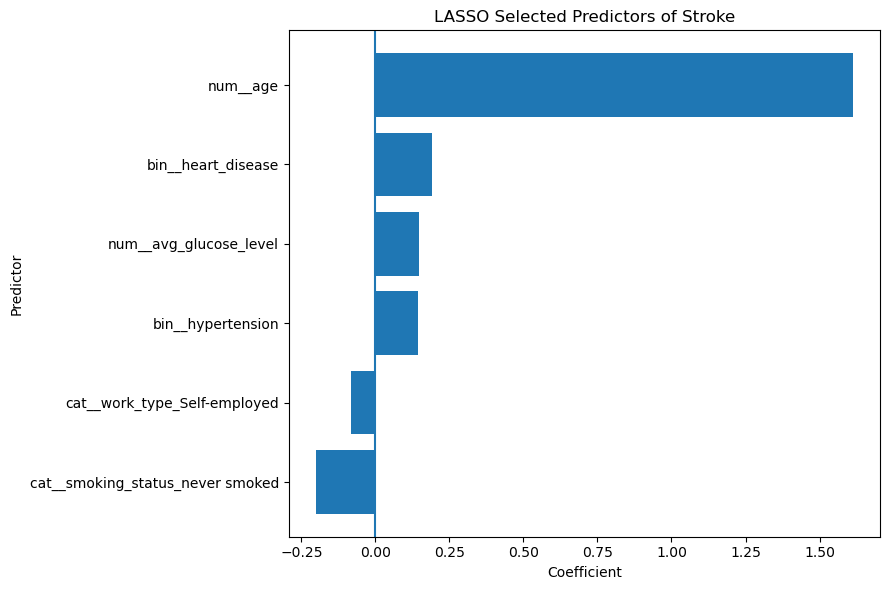

In [22]:
plot_lasso = lasso_selected.sort_values(
    "Coefficient"
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_lasso["Feature"],
    plot_lasso["Coefficient"]
)

plt.axvline(0)

plt.title("LASSO Selected Predictors of Stroke")
plt.xlabel("Coefficient")
plt.ylabel("Predictor")

plt.tight_layout()
plt.show()

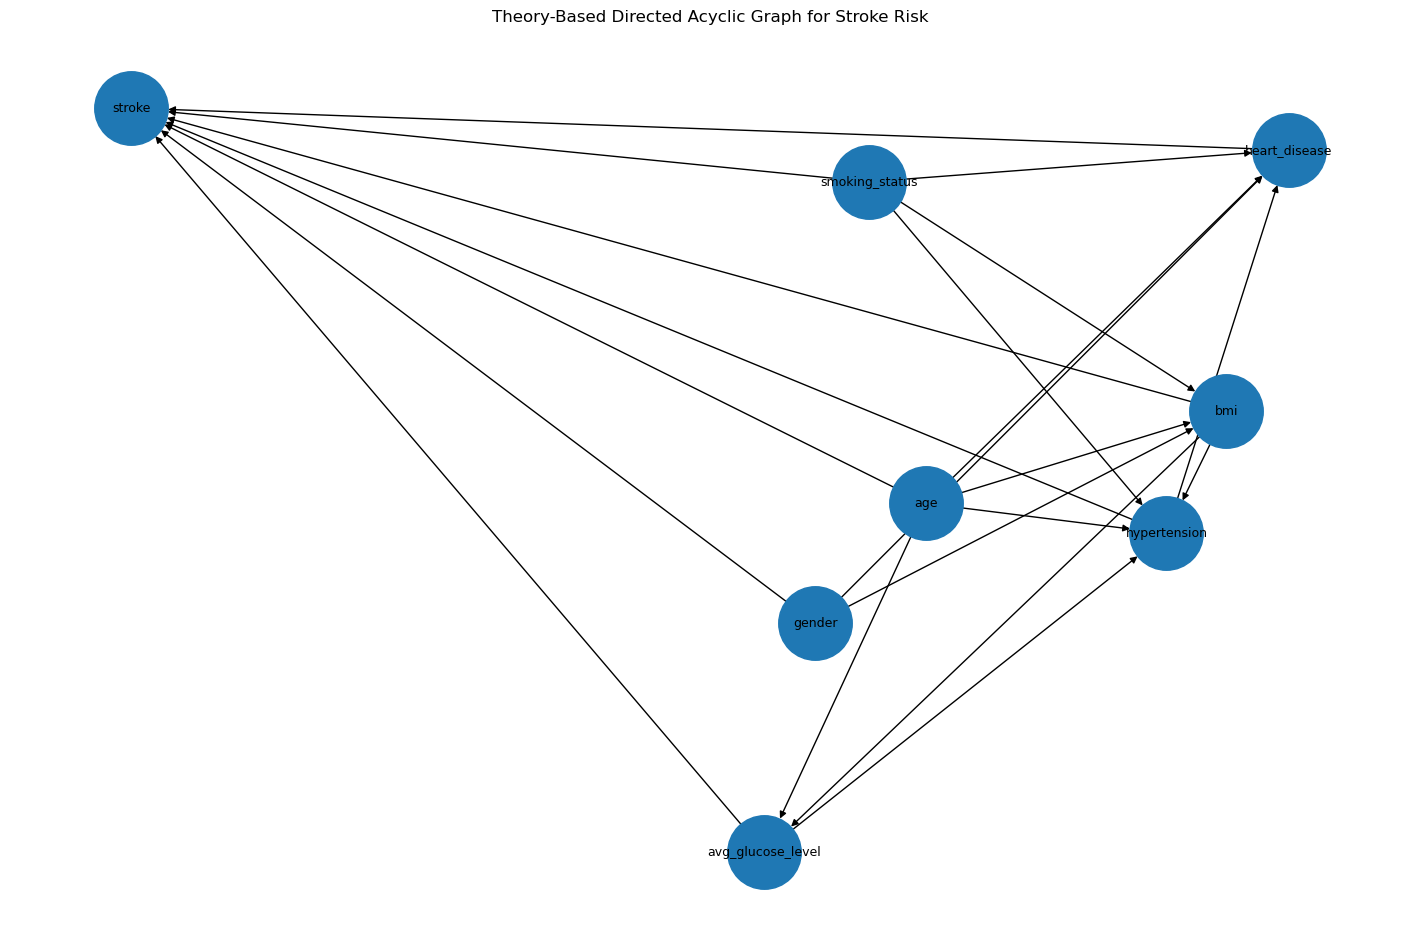

In [23]:
dag = nx.DiGraph()

dag_edges = [
    ("age", "bmi"),
    ("age", "avg_glucose_level"),
    ("age", "hypertension"),
    ("age", "heart_disease"),
    ("age", "stroke"),

    ("gender", "bmi"),
    ("gender", "heart_disease"),
    ("gender", "stroke"),

    ("smoking_status", "bmi"),
    ("smoking_status", "hypertension"),
    ("smoking_status", "heart_disease"),
    ("smoking_status", "stroke"),

    ("bmi", "avg_glucose_level"),
    ("bmi", "hypertension"),
    ("bmi", "stroke"),

    ("avg_glucose_level", "hypertension"),
    ("avg_glucose_level", "stroke"),

    ("hypertension", "heart_disease"),
    ("hypertension", "stroke"),

    ("heart_disease", "stroke")
]

dag.add_edges_from(dag_edges)

plt.figure(figsize=(14, 9))

pos = nx.spring_layout(
    dag,
    seed=RANDOM_STATE
)

nx.draw(
    dag,
    pos,
    with_labels=True,
    node_size=2800,
    font_size=9,
    arrows=True
)

plt.title("Theory-Based Directed Acyclic Graph for Stroke Risk")
plt.show()

In [24]:
target = "stroke"

parents = set(dag.predecessors(target))
children = set(dag.successors(target))

co_parents = set()

for child in children:
    co_parents.update(dag.predecessors(child))

markov_blanket = (
    parents |
    children |
    co_parents
) - {target}

print("Parents of stroke:")
print(sorted(parents))

print("\nChildren of stroke:")
print(sorted(children))

print("\nTheory-based Markov Blanket of stroke:")
print(sorted(markov_blanket))

Parents of stroke:
['age', 'avg_glucose_level', 'bmi', 'gender', 'heart_disease', 'hypertension', 'smoking_status']

Children of stroke:
[]

Theory-based Markov Blanket of stroke:
['age', 'avg_glucose_level', 'bmi', 'gender', 'heart_disease', 'hypertension', 'smoking_status']


In [25]:
causal_features = [
    "age",
    "gender",
    "hypertension",
    "heart_disease",
    "avg_glucose_level",
    "bmi",
    "smoking_status"
]

X_causal = df[causal_features].copy()
y_causal = df["stroke"]

causal_numeric = [
    "age",
    "avg_glucose_level",
    "bmi"
]

causal_binary = [
    "hypertension",
    "heart_disease"
]

causal_categorical = [
    "gender",
    "smoking_status"
]

causal_preprocessor = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]),
        causal_numeric
    ),
    (
        "bin",
        SimpleImputer(strategy="most_frequent"),
        causal_binary
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ))
        ]),
        causal_categorical
    )
])

causal_model = Pipeline([
    ("preprocessor", causal_preprocessor),
    ("model", LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

causal_model.fit(X_causal, y_causal)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'avg_glucose_level',
                                                   'bmi']),
                                                 ('bin',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  ['hypertension',
                                                   'heart_disease']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['gender',
                                                   'smoking_status'])])),
                ('model', LogisticRegression(max_iter=5000, random_state=823))])

In [26]:
do_no_hypertension = X_causal.copy()
do_hypertension = X_causal.copy()

do_no_hypertension["hypertension"] = 0
do_hypertension["hypertension"] = 1

risk_no_hypertension = causal_model.predict_proba(
    do_no_hypertension
)[:, 1].mean()

risk_hypertension = causal_model.predict_proba(
    do_hypertension
)[:, 1].mean()

risk_difference = (
    risk_hypertension -
    risk_no_hypertension
)

print(
    f"Modeled stroke risk under hypertension = 0: "
    f"{risk_no_hypertension:.4f}"
)

print(
    f"Modeled stroke risk under hypertension = 1: "
    f"{risk_hypertension:.4f}"
)

print(
    f"Modeled risk difference: "
    f"{risk_difference:.4f}"
)

Modeled stroke risk under hypertension = 0: 0.0452
Modeled stroke risk under hypertension = 1: 0.0632
Modeled risk difference: 0.0180


In [27]:
temporal_order = pd.DataFrame({
    "Order": [1, 2, 3, 3, 4, 4, 5],
    "Variable": [
        "Age",
        "Smoking Status",
        "BMI",
        "Average Glucose Level",
        "Hypertension",
        "Heart Disease",
        "Stroke"
    ],
    "Stage": [
        "Demographic",
        "Lifestyle",
        "Metabolic",
        "Metabolic",
        "Clinical Condition",
        "Clinical Condition",
        "Outcome"
    ]
})

temporal_order

,Order,Variable,Stage
0,1,Age,Demographic
1,2,Smoking Status,Lifestyle
2,3,BMI,Metabolic
3,3,Average Glucose Level,Metabolic
4,4,Hypertension,Clinical Condition
5,4,Heart Disease,Clinical Condition
6,5,Stroke,Outcome


In [28]:
network_df = df[
    [
        "age",
        "bmi",
        "avg_glucose_level",
        "hypertension",
        "heart_disease",
        "stroke"
    ]
].copy()

network_df["bmi"] = network_df["bmi"].fillna(
    network_df["bmi"].median()
)

network_df.head()


variable_order = [
    "age",
    "bmi",
    "avg_glucose_level",
    "hypertension",
    "heart_disease",
    "stroke"
]

binary_targets = {
    "hypertension",
    "heart_disease",
    "stroke"
}

regression_edges = []

for i, target in enumerate(variable_order[1:], start=1):

    predictors = variable_order[:i]

    X_reg = sm.add_constant(
        network_df[predictors],
        has_constant="add"
    )

    y_reg = network_df[target]

    if target in binary_targets:
        model = sm.Logit(
            y_reg,
            X_reg
        ).fit(
            disp=False,
            maxiter=200
        )

    else:
        model = sm.OLS(
            y_reg,
            X_reg
        ).fit()

    for predictor in predictors:

        coefficient = model.params[predictor]
        p_value = model.pvalues[predictor]

        if p_value < 0.05:

            regression_edges.append({
                "From": predictor,
                "To": target,
                "Coefficient": coefficient,
                "P_Value": p_value
            })

regression_results = pd.DataFrame(
    regression_edges
)

regression_results

,From,To,Coefficient,P_Value
0,age,bmi,0.110422,1.924466e-125
1,age,avg_glucose_level,0.411901,5.035332e-46
2,bmi,avg_glucose_level,0.589148,2.773011e-12
3,age,hypertension,0.052091,9.121784e-59
4,bmi,hypertension,0.054254,1.131854e-16
5,avg_glucose_level,hypertension,0.004518,3.713980e-07
6,age,heart_disease,0.074445,2.635927e-49
7,avg_glucose_level,heart_disease,0.006097,5.082066e-08
8,age,stroke,0.068875,4.159062e-40
9,avg_glucose_level,stroke,0.004136,4.917641e-04


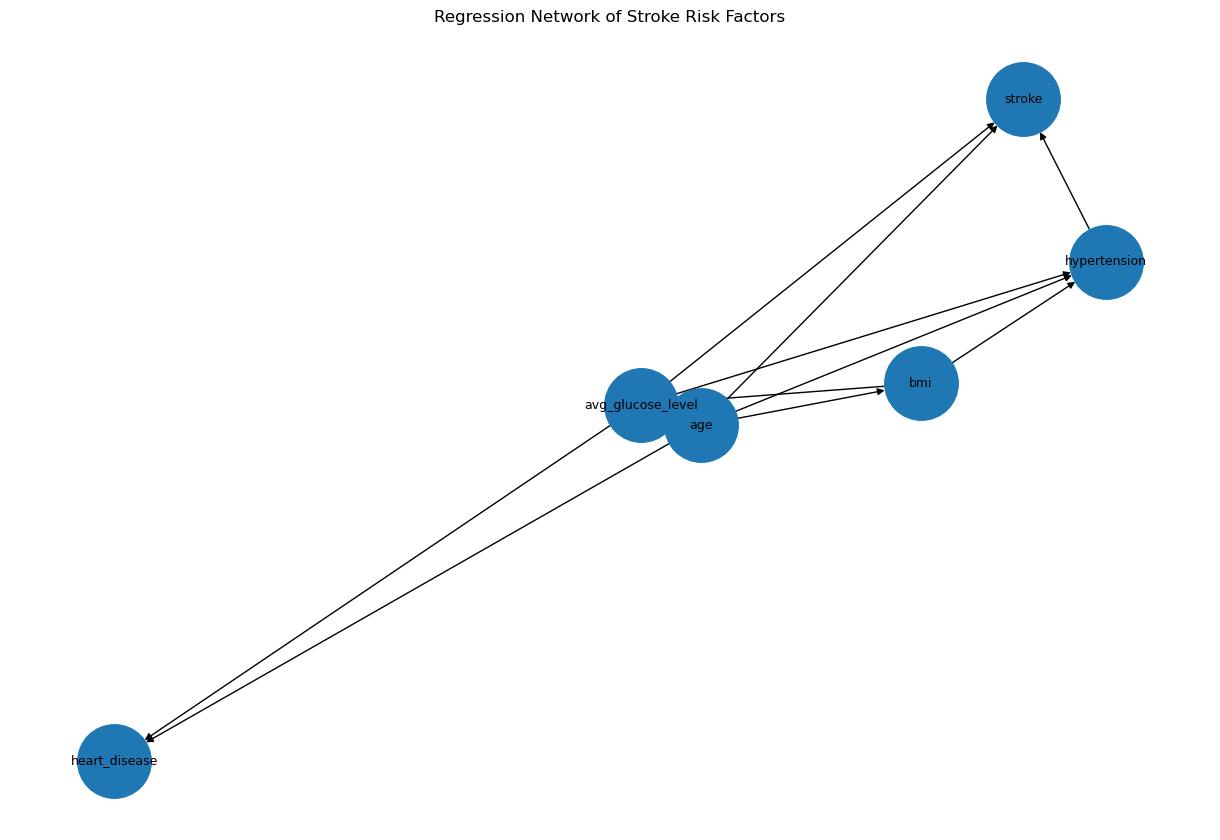

In [29]:
regression_graph = nx.DiGraph()

for _, row in regression_results.iterrows():

    regression_graph.add_edge(
        row["From"],
        row["To"]
    )

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(
    regression_graph,
    seed=RANDOM_STATE
)

nx.draw(
    regression_graph,
    pos,
    with_labels=True,
    node_size=2800,
    font_size=9,
    arrows=True
)

plt.title("Regression Network of Stroke Risk Factors")
plt.show()

In [30]:
mediation_df = df[
    [
        "age",
        "avg_glucose_level",
        "bmi",
        "heart_disease",
        "stroke"
    ]
].copy()

mediation_df["bmi"] = mediation_df["bmi"].fillna(
    mediation_df["bmi"].median()
)

mediator_model = smf.ols(
    "avg_glucose_level ~ age + bmi",
    data=mediation_df
).fit()

outcome_model = smf.logit(
    "stroke ~ age + avg_glucose_level + bmi + heart_disease",
    data=mediation_df
).fit(
    disp=False,
    maxiter=200
)

a_path = mediator_model.params["age"]

b_path = outcome_model.params[
    "avg_glucose_level"
]

direct_age = outcome_model.params["age"]

indirect_effect = a_path * b_path

print(f"A path: {a_path:.6f}")
print(f"B path: {b_path:.6f}")
print(f"Direct age coefficient: {direct_age:.6f}")
print(
    f"Approximate indirect effect: "
    f"{indirect_effect:.6f}"
)

A path: 0.411901
B path: 0.004447
Direct age coefficient: 0.070586
Approximate indirect effect: 0.001832


In [31]:
rng = np.random.default_rng(
    RANDOM_STATE
)

bootstrap_indirect = []

for i in range(500):

    indices = rng.integers(
        0,
        len(mediation_df),
        len(mediation_df)
    )

    sample = mediation_df.iloc[
        indices
    ]

    try:

        mediator_boot = smf.ols(
            "avg_glucose_level ~ age + bmi",
            data=sample
        ).fit()

        outcome_boot = smf.logit(
            "stroke ~ age + avg_glucose_level + bmi + heart_disease",
            data=sample
        ).fit(
            disp=False,
            maxiter=200
        )

        indirect_boot = (
            mediator_boot.params["age"]
            *
            outcome_boot.params[
                "avg_glucose_level"
            ]
        )

        bootstrap_indirect.append(
            indirect_boot
        )

    except:
        pass

lower_ci, upper_ci = np.percentile(
    bootstrap_indirect,
    [2.5, 97.5]
)

print(
    f"Approximate indirect effect: "
    f"{indirect_effect:.6f}"
)

print(
    f"95% Bootstrap CI: "
    f"[{lower_ci:.6f}, {upper_ci:.6f}]"
)

Approximate indirect effect: 0.001832
95% Bootstrap CI: [0.000791, 0.002841]


In [32]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

logistic_model.fit(
    X_train,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_test
)

logistic_probabilities = logistic_model.predict_proba(
    X_test
)[:, 1]

print(
    classification_report(
        y_test,
        logistic_predictions,
        digits=3
    )
)


logistic_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        logistic_predictions
    ),
    "Precision": precision_score(
        y_test,
        logistic_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        logistic_predictions
    ),
    "F1": f1_score(
        y_test,
        logistic_predictions
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        logistic_probabilities
    )
}

pd.DataFrame(
    [logistic_metrics],
    index=["Logistic Regression"]
)


random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = random_forest_model.predict(
    X_test
)

rf_probabilities = random_forest_model.predict_proba(
    X_test
)[:, 1]

print(
    classification_report(
        y_test,
        rf_predictions,
        digits=3,
        zero_division=0
    )
)

rf_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        rf_predictions
    ),
    "Precision": precision_score(
        y_test,
        rf_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        rf_predictions
    ),
    "F1": f1_score(
        y_test,
        rf_predictions
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        rf_probabilities
    )
}

pd.DataFrame(
    [rf_metrics],
    index=["Random Forest"]
)

              precision    recall  f1-score   support

           0      0.986     0.731     0.840       972
           1      0.133     0.800     0.228        50

    accuracy                          0.735      1022
   macro avg      0.560     0.766     0.534      1022
weighted avg      0.944     0.735     0.810      1022

              precision    recall  f1-score   support

           0      0.951     0.999     0.974       972
           1      0.000     0.000     0.000        50

    accuracy                          0.950      1022
   macro avg      0.476     0.499     0.487      1022
weighted avg      0.905     0.950     0.927      1022



,Accuracy,Precision,Recall,F1,ROC_AUC
Random Forest,0.950098,0.0,0.0,0.0,0.827222


In [33]:
model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **logistic_metrics
    },
    {
        "Model": "Random Forest",
        **rf_metrics
    }
])

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.734834,0.13289,0.8,0.22792,0.847613
1,Random Forest,0.950098,0.00000,0.0,0.00000,0.827222


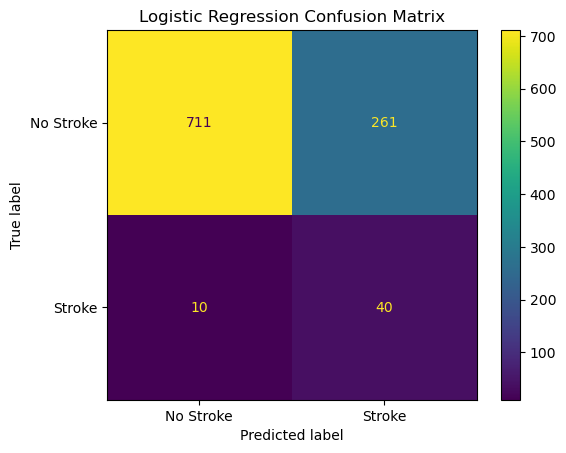

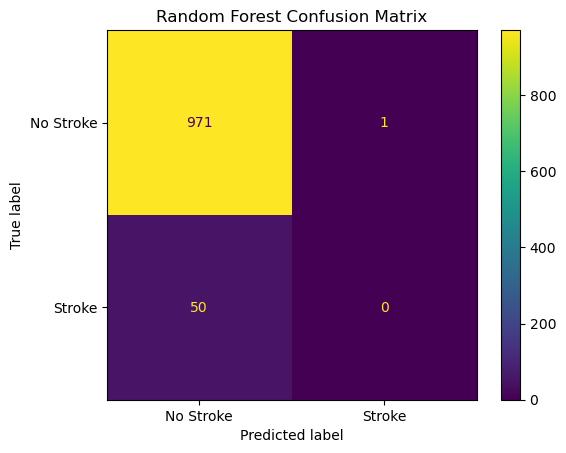

In [34]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    display_labels=[
        "No Stroke",
        "Stroke"
    ]
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()


ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    display_labels=[
        "No Stroke",
        "Stroke"
    ]
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

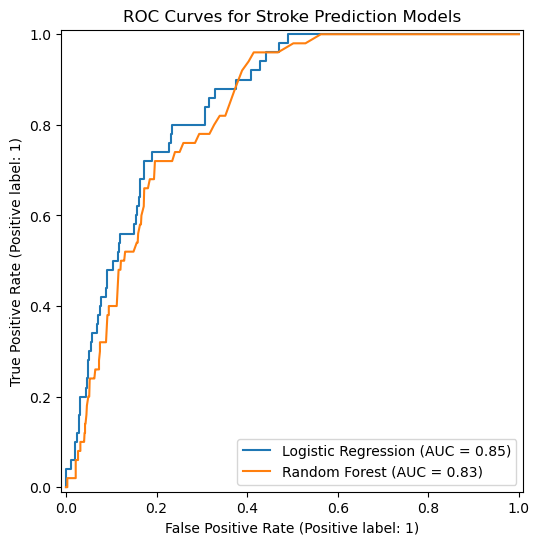

In [35]:
fig, ax = plt.subplots(
    figsize=(8, 6)
)

RocCurveDisplay.from_predictions(
    y_test,
    logistic_probabilities,
    name="Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_probabilities,
    name="Random Forest",
    ax=ax
)

plt.title(
    "ROC Curves for Stroke Prediction Models"
)

plt.show()

In [36]:
best_auc_row = model_comparison.loc[
    model_comparison["ROC_AUC"].idxmax()
]

best_recall_row = model_comparison.loc[
    model_comparison["Recall"].idxmax()
]

print("SUMMARY")
print("---------------------")

print(
    f"Dataset observations: {len(df)}"
)

print(
    f"Stroke cases: {df['stroke'].sum()}"
)

print(
    f"Stroke prevalence: "
    f"{df['stroke'].mean() * 100:.2f}%"
)

print(
    f"\nHighest ROC-AUC model: "
    f"{best_auc_row['Model']}"
)

print(
    f"ROC-AUC: "
    f"{best_auc_row['ROC_AUC']:.3f}"
)

print(
    f"\nHighest recall model: "
    f"{best_recall_row['Model']}"
)

print(
    f"Recall: "
    f"{best_recall_row['Recall']:.3f}"
)

SUMMARY
---------------------
Dataset observations: 5110
Stroke cases: 249
Stroke prevalence: 4.87%

Highest ROC-AUC model: Logistic Regression
ROC-AUC: 0.848

Highest recall model: Logistic Regression
Recall: 0.800
